In [1]:
#calculate synaptic changes in paraeter sets for each learning rule   Fig 1E

import os
import sys
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from scipy import integrate
import math
from scipy.integrate import odeint
from multiprocessing import Process
import multiprocessing
from scipy import interpolate
from tqdm import tqdm
from numba import jit,  njit, i8, f8

from collections import deque
import itertools
import numpy as np

from datetime import datetime

import pandas as pd
fs = 20
fs_l = 15

In [2]:
# pars = default_pars_STDP()
rho_star = 0.5
zeta = 1

beta = 0.5
b=  5
g_nmdar = 0.0138403
g_cav_s = 0.050580

a_ca = 0.5
x_a = 34.8
x_tau = 0.2
s_a = 5
s_tau = 10
Vca = 120     # spike threshold [mV]
vrest = -70 # reset potential [mV]


area = 0.02

@jit(i8[:](f8[:], i8,i8,f8,f8[:], f8[:],f8,f8,i8,i8, f8,f8,f8,f8,i8))
def Solvers(init, Lt, offset, dt, mp_pre, mp_post, cpre_r, cpost_r, sum_p, sum_d, th_p, th_d, tau_ca_pre, tau_ca_post, solver):
    th_p = th_p #1.0871859
    th_d = th_d #0.65795
#     gp= gp #1454.49501
#     gd= gd #325.078706
    tau_ca_pre=tau_ca_pre #25
    tau_ca_post= tau_ca_post# 26.68402
#     sig=sig #2.03806
#     tau_s=tau_s #145447
    
    rho_star = 0.5
    zeta = 1
    area = 0.02

    beta = 0.5
    b=  5
    g_nmdar = 0.0138403
    g_cav_s = 0.050580

    a_ca = 0.5
    x_a = 34.8
    x_tau = 0.2
    s_a = 5
    s_tau = 10
    Vca = 120     # spike threshold [mV]
    vrest = -70 # reset potential [mV]


    
        
    
    def dAlldt(init, mp_pre, mp_post, it, cpre_r, cpost_r):
        
#         def nmda_f(v):
#             return 1.0 / (1.0 + np.exp(-(v-20)/2.0))
  
#         def inf_m(v):
#             return 1.0 / (1.0 + np.exp(-(v+20)/9))
        x = init[0]
        s = init[1]
        cpre = init[2]
        cpost = init[3]
        ca = cpre + cpost
        nmda_f = 1.0 / (1.0 + np.exp(-(mp_pre[it]-20)/2.0))
        
        dxdt = (x_a * nmda_f - x/x_tau)
        dsdt = (s_a * x * (1-s) - s/s_tau)
        i_nmda = (g_nmdar * s * (vrest-Vca))*cpre_r
        
        inf_m=1.0 / (1.0 + np.exp(-(mp_post[it]+20)/9))
        
        i_vdcc_s = (g_cav_s * (inf_m)**2 * (mp_post[it]-Vca))*cpost_r
        dcpre = (- (a_ca * (i_nmda))- cpre/tau_ca_pre)
        dcpost = (- (a_ca * (i_vdcc_s)*10*area) - cpost/tau_ca_post)
        dcadt =  dcpre + dcpost 
        ode = np.array([dxdt,dsdt, dcpre, dcpost])
        return ode
    
    for it in range(Lt):
        if it==0:
            continue
        cpre = init[2]
        cpost = init[3]
        ca = cpre + cpost


        if ca > th_p and it >= offset/dt:
            C_th_p = 1
            sum_p += 1
        else:
            C_th_p=0

        if ca > th_d and it >= offset/dt:
            C_th_d = 1
            sum_d += 1
        else:
            C_th_d = 0
        # 4th order Runge-Kutta 法
        if solver == 1:
            k1 = dt*dAlldt(init, mp_pre, mp_post, it, cpre_r, cpost_r, th_p, th_d, tau_ca_pre, tau_ca_post)
            k2 = dt*dAlldt(init + 0.5*k1, mp_pre, mp_post, it, cpre_r, cpost_r, th_p, th_d, tau_ca_pre, tau_ca_post)
            k3 = dt*dAlldt(init + 0.5*k2, mp_pre, mp_post,it, cpre_r, cpost_r, th_p, th_d, tau_ca_pre, tau_ca_post)
            k4 = dt*dAlldt(init + k3, mp_pre, mp_post, it, cpre_r, cpost_r, th_p, th_d, tau_ca_pre, tau_ca_post)
            init = init + (k1 + 2*k2 + 2*k3 + k4) / 6
            # 陽的 Euler 法
        elif solver == 0:
            init = init + dt*dAlldt(init, mp_pre, mp_post, it, cpre_r, cpost_r, th_p, th_d, tau_ca_pre, tau_ca_post)
    
    return np.array([sum_p, sum_d])

In [3]:

# simple 1Hz spikes -> MP
def gen_spikes(T, off, dt, n, interval,lag):

        spikes= np.zeros((2,int((T)/dt)))
        
        for i in range(n):
          
            if int(off/dt)+i*int(interval/dt) < int((T+off)/dt):
                spikes[0][int(off/dt)+i*int(interval/dt)] = 1
            if int(off/dt)+i*int(interval/dt) + int(lag/dt) < int((T+off)/dt):
                spikes[1][int(off/dt)+i*int(interval/dt) + int(lag/dt)]=1
       
        return spikes
    
def sp_to_mp_2(spikes, T, off ,peak, fx,fy, lx,ly, vrest):
    Lt = int((T)/dt)
    pre_x = np.arange(0,Lt,1)* spikes[0]
    pre_y = spikes[0]*peak
    post_x = np.arange(0,Lt,1)* spikes[1]
    post_y = spikes[1]*peak
    for m,j in enumerate(spikes[0]):
        if j==1:
            #if m+10 < spikes.shape[1]-2*off/dt:
                pre_x[m+lx]=pre_x[m] + lx
                pre_y[m+lx]= ly
            #if m-36 >=off/dt:
                pre_x[m+fx]=pre_x[m] + fx
                pre_y[m+fx]= fy

    for m,j in enumerate(spikes[1]):
        if j==1:
            #if m+10 < spikes.shape[1]-2*off/dt:#10000
                post_x[m+lx]=post_x[m] + lx
                post_y[m+lx]= ly
            #if m-36 >=off/dt:
                post_x[m+fx]=post_x[m] +fx
                post_y[m+fx]= fy
                

    pre_x_a = np.take(pre_x, np.nonzero(pre_x)[0])
    pre_y_a = np.take(pre_y, np.nonzero(pre_y)[0])
    post_x_a = np.take(post_x, np.nonzero(post_x)[0])
    post_y_a = np.take(post_y, np.nonzero(post_y)[0])

    af = (peak-fy)/(0-fx)
    xf_pre = int(pre_x_a[0]-(pre_y_a[0]-vrest)/af)
    xl_pre = int(pre_x_a[-1]+int(3/dt))  #3ms で過分極から戻る
    xf_post = int(post_x_a[0]-(post_y_a[0]-vrest)/af)
    xl_post = int(post_x_a[-1]+int(3/dt))
    pre_x_a = np.insert(pre_x_a,0,xf_pre)
    pre_x_a = np.append(pre_x_a,xl_pre)
    pre_y_a = np.insert(pre_y_a,0,vrest)
    pre_y_a = np.append(pre_y_a,vrest)
    post_x_a = np.insert(post_x_a,0,xf_post)
    post_x_a = np.append(post_x_a,xl_post)
    post_y_a = np.insert(post_y_a,0,vrest)
    post_y_a = np.append(post_y_a,vrest)

    x_latent_post = np.arange(min(post_x_a), max(post_x_a)+1, 1).astype("int32")
    x_latent_pre = np.arange(min(pre_x_a), max(pre_x_a)+1, 1).astype("int32")
    
     #ip1 = ["最近傍点補間", lambda x, y: interpolate.interp1d(x, y, kind="nearest",  fill_value="extrapolate")]
    ip2 = ["線形補間", lambda x, y: interpolate.interp1d(x,y,fill_value="extrapolate")]
    for method_name, method in [ip2]:
       # print(method_name)
        fitted_curve_pre = method(pre_x_a, pre_y_a)
        fitted_curve_post = method(post_x_a, post_y_a)
    middle_pre = fitted_curve_pre(x_latent_pre)
    middle_post = fitted_curve_post(x_latent_post)

    first_pre = np.ones(x_latent_pre[0])*vrest
    last_pre = np.ones(Lt-1-x_latent_pre[-1])*vrest
    first_post = np.ones(x_latent_post[0])*vrest
    last_post = np.ones(Lt-1-x_latent_post[-1])*vrest
    mp_pre = np.append(first_pre,middle_pre).astype("float64")
    mp_pre = np.append(mp_pre,last_pre).astype("float64")
    mp_post = np.append(first_post,middle_post).astype("float64")
    mp_post = np.append(mp_post,last_post).astype("float64")
   
    return mp_pre, mp_post


class area_gd:
    def __init__(self, pars, T, offset, dt, cpre_r, cpost_r, solvers = 0):
        self.T = T
        self.offset = offset
        self.dt = dt
        self.presum_p = 0
        self.presum_d = 0
        self.postsum_p = 0
        self.postsum_d = 0 
        self.init = np.array([0.01,0.01,0,0])
        self.tc = 0
        self.th_p = pars["th_p"]
        self.th_d = pars["th_d"]
        self.gp= pars["gp"]
        self.gd= pars["gd"]
        self.tau_ca_pre =    pars["tau_ca_pre"] 
        self.tau_ca_post =   pars["tau_ca_post"]
        self.sig= pars["sig"] 
        self.tau_s = pars["tau_s"]
        self.pars = pars
        self.sol_num = solvers
        self.cpre_r = cpre_r
        self.cpost_r = cpost_r
        self.area=0.02

    def dAlldt_area(self, init, mp_pre, mp_post, it):

        x = init[0]
        s = init[1]
        cpre = init[2]
        cpost = init[3]
       # print("cpost", cpost.shape)
        ca = cpre + cpost#init[4]
    #     print("mppres", mp_pres[:,it].shape)
    #     print("x", x.shape)
        dxdt = (x_a * self.nmda_f0(mp_pre[it]) - x/x_tau)
        dsdt = (s_a * x * (1-s) - s/s_tau)

        i_nmda = (g_nmdar * s * (vrest-120))*self.cpre_r
        i_vdcc_s = (g_cav_s * (self.inf_m0(mp_post[it]))**2 * (mp_post[it]-Vca))*self.cpost_r

        dcpre = (- (a_ca * (i_nmda))- cpre/self.tau_ca_pre)
        dcpost = (- (a_ca * (i_vdcc_s)*10*self.area) - cpost/self.tau_ca_post)
       # dcpost = np.tile(dcpost, NE).reshape(-1,1)
        dcadt =  dcpre + dcpost #(- a_ca * (i_nmda + i_vdcc_s) - ca/tau_ca_syn)
   
        ode = np.array([dxdt,dsdt, dcpre, dcpost])
        return ode
    
    def Solvers_area(self, func, init,  mp_pre, mp_post,it, solver=0):
        cpre = init[2]
        cpost = init[3]
        if cpre  > self.th_p and it > self.offset/self.dt:
            self.presum_p +=1
        if cpre  > self.th_d and it > self.offset/self.dt:
            self.presum_d +=1
        if cpost  > self.th_p and it > self.offset/self.dt: 
            self.postsum_p +=1
        if cpost  > self.th_d and it > self.offset/self.dt:
            self.postsum_d +=1
        # 4th order Runge-Kutta 法
        if solver == 1:
            k1 = dt*func(init, mp_pre, mp_post, it)
            k2 = dt*func(init + 0.5*k1, mp_pre, mp_post, it)
            k3 = dt*func(init + 0.5*k2, mp_pre, mp_post,it)
            k4 = dt*func(init + k3, mp_pre, mp_post, it)
            return init + (k1 + 2*k2 + 2*k3 + k4) / 6
            # 陽的 Euler 法
        elif solver == 0:
            return init + dt*func(init, mp_pre, mp_post, it)
        else:
            return None
    
    def run_ode_np_area(self, mp_pre, mp_post):
        Lt = int((self.T)/self.dt)


        X_arr = np.zeros((4, Lt))
        X_arr[:,0] = self.init

        for it in range(Lt):

            init = self.Solvers_area(self.dAlldt_area, self.init,  mp_pre, mp_post, it, self.sol_num)
            self.init = init
            #print("init", init.shape)
            X_arr[:,it] = init

        init_t = int(self.offset/self.dt)

        cpre_amp = np.max(X_arr[2][init_t:])
        cpost_amp = np.max(X_arr[3][init_t:])
#         print("cpre_amp", cpre_amp)
#         print("cpost_amp", cpost_amp)
        
#         print("pre_sump",self.presum_p)
#         print("pre_sumd",self.presum_d)
#         print("post_sump",self.postsum_p)
#         print("post_sumd",self.postsum_d)
#         if (cpre_amp > self.th_p and cpre_amp > self.th_d) or (cpost_amp > self.th_p and cpost_amp > self.th_d):
#             gr = (self.postsum_d+self.presum_d)/(self.postsum_p+self.presum_p)
#           #  print("gr", gr)
#             gd = self.gp/gr
#            # print("gd", gd)
#         else:
#             gd=self.gd
        
#         self.pars["gd"] = gd
        
        
        
        return self.pars, X_arr[2,:], X_arr[3,:]
        
    def nmda_f0(self, v):
        return 1.0 / (1.0 + np.exp(-(v-20)/2.0))

    def inf_m0(self, v):
        return 1.0 / (1.0 + np.exp(-(v+20)/9))



def run_ode_lr(lag, T, offset, dt, cpre_r, cpost_r, mp_pre, mp_post,  syn_c_dic, gp, gd, th_p, th_d, tau_ca_pre, tau_ca_post, sig, taus):


    Lt=int((T)/dt)
    
    peak =13  #12.692
    fx,fy = int(-0.8/dt),-68  #down to up
    lx,ly = int(0.8/dt), -76  #down
    vrest = -70

    off = 200 #ms 
    n=3
    interval = 1000 #ms
    stim_T = n *interval
    
    spikes_stim = gen_spikes(stim_T,off,dt,n,interval,lag)
    mp_pre, mp_post =sp_to_mp_2(spikes_stim, stim_T,off, peak, fx, fy, lx, ly, vrest)
  

    init_t = 0
    cpre = 0
    cpost = 0
#     ca = 0
    x_n= 0.01
    s_n = 0.01
    
    init = np.array([x_n,s_n,cpre,cpost])
    
    sum_p = 0
    sum_d = 0
    
   
    sums = Solvers(init, Lt, offset, dt, mp_pre, mp_post, cpre_r, cpost_r, 
                                  sum_p, sum_d,th_p, th_d, tau_ca_pre, tau_ca_post, 1)
    sum_p = sums[0]
    sum_d = sums[1]
#     print("gd",gd)
#     print("sum_p", sum_p)
#     print("sum_d", sum_d)
#     ap = sum_p*60/(60000/dt)
#     ad = sum_d*60/(60000/dt)
    ap = sum_p*60/(60000/dt)
    ad = sum_d*60/(60000/dt)
#     print("ap",ap*gp)
#     print("ad",ad*gd)
    
    try:
        rho_b = gp*ap/(gp*ap+gd*ad)
        sig_r = np.sqrt(sig*sig*(ap+ad)/(gp*ap+gd*ad))
        tau_eff = (tau_s/dt)/(gp*ap+gd*ad)
        sig_r0 = 0
        
        u= U_p(0,rho_b,rho_star,sig_r,tau_eff,60,interval/dt)
        d = D_p(1,rho_b,rho_star,sig_r,tau_eff,60,interval/dt)
        #print("u",u)
#         u0= U_p(0,rho_b,s_star,sig_r0,tau_eff,n,interval)
#         d0 = D_p(1,rho_b,s_star,sig_r0,tau_eff,n,interval)
        
        syn_c = ((1-u)*beta+d*(1-beta)+b*(u*beta+(1-d)*(1-beta)))/(beta+(1-beta)*b)
#         syn_c0 = ((1-u0)*beta+d0*(1-beta)+b*(u0*beta+(1-d0)*(1-beta)))/(beta+(1-beta)*b)
        if syn_c<0:    
            syn_c=0
    except ZeroDivisionError as e:
        print("zerodiv")
        rho_b = 0.5
        #sig_r = 0
        #tau_eff = tau_s*1000/(gp*ap+gd*ad) 
        syn_c = 1.0
#         syn_c0=1.0
    syn_c_dic[int(lag)] = syn_c
#     print("lag {}, syn_c {}".format(lag, syn_c))
    return syn_c, cpre, cpost #, syn_c0        
     
    
from scipy import integrate
import math
def erf(x):
   # 2/np.sqrt(np.pi)
    y=lambda t: math.exp(-t*t)
    integ = integrate.quad(y, 0, x)
    v =2/np.sqrt(np.pi)*integ[0]
    #np.linspace = (0,x,1000)
    #print("erf", v)
    return v

def U_p(rho_0,rho_b,rho_star,sig_r,tau_eff,n,interval):
    x=(rho_star-rho_b+(rho_b-rho_0)*np.exp(-n*interval/tau_eff))/(np.sqrt(sig_r*sig_r*(1-np.exp(-2*n*interval/tau_eff))))
    eul = erf(-x)
    u= 1/2*(1+eul)
    #print("u_x", x)
    return u

def D_p(rho_0,rho_b,rho_star,sig_r,tau_eff,n,interval):
    x=(rho_star-rho_b+(rho_b-rho_0)*np.exp(-n*interval/tau_eff))/(np.sqrt(sig_r*sig_r*(1-np.exp(-2*n*interval/tau_eff))))
    eul = erf(-x)
    d= 1/2*(1-eul)
    #print("d_x", x)
    return d



def fitting_curve(lr_li, lag_li, lag_step, syn_c_sorted, amp, tau,dx_li):
    esqs = np.zeros(4)
    dxs = np.zeros(4)
    
    esqs[0], dxs[0] = gaus_fit(lag_li, syn_c_sorted, amp, amp, tau,dx_li)
    esqs[1], dxs[1] = gaus_fit(lag_li, syn_c_sorted, -amp, -amp, tau,dx_li)
    esqs[2], dxs[2] = gaus_fit(lag_li, syn_c_sorted, -amp, amp, tau,dx_li)
    esqs[3], dxs[3] = gaus_fit(lag_li, syn_c_sorted, amp, -amp, tau,dx_li)
    
    min_esq = np.min(esqs)
   # print("min_residual", min_esq)
    min_dx = dxs[np.argmin(esqs)]
    lr_index = np.argmin(esqs)
    #print(lr_li[lr_index])
    return lr_index, min_esq, min_dx

def gaus_fit(lag_li, syn_c_sorted, a, b, tau, dx_li):
    esq_li = []
    for dx in dx_li:
    
        xl = np.arange(lag_li[0], -dx*lag_step, lag_step)
        xr = np.arange(-dx*lag_step, lag_li[-1]+lag_step/2, lag_step)
    
        yl = a*np.exp(-(xl+dx*lag_step)**2/tau**2)
        yr = b*np.exp(-(xr+dx*lag_step)**2/tau**2)
    
        y=np.append(yl, yr)

        y=y+1
        esq = np.sum((syn_c_sorted-y)*(syn_c_sorted-y))
        esq_li.append(esq)
    min_esq = np.min(esq_li)
    min_dx = dx_li[np.argmin(esq_li)]
    return min_esq, min_dx


def repro_wave(lr_index, lag_li, sync_li, lag_step, amp, tau, dx, gauss=True):
    xl = np.arange(lag_li[0], -dx*lag_step, lag_step)
    xr = np.arange(-dx*lag_step, lag_li[-1]+lag_step/2, lag_step)
    if lr_index == 0:
        a = amp
        b = amp
        yl = a*np.exp(-(xl+dx*lag_step)**2/tau**2)
        yr = b*np.exp(-(xr+dx*lag_step)**2/tau**2)
    if lr_index == 1:
        a = -amp
        b= -amp
        yl = a*np.exp(-(xl+dx*lag_step)**2/tau**2)
        yr = b*np.exp(-(xr+dx*lag_step)**2/tau**2)
    
    if lr_index == 2: 
        a = -amp
        b= amp
        yl = a*np.exp(-(xl+dx*lag_step)**2/tau**2)
        yr = b*np.exp(-(xr+dx*lag_step)**2/tau**2)
    
    
    if lr_index == 3:
        a = amp
        b= -amp
        yl = a*np.exp(-(xl+dx*lag_step)**2/tau**2)
        yr = b*np.exp(-(xr+dx*lag_step)**2/tau**2)

    y=np.append(yl, yr)
    y=y+1


    plt.figure(figsize=(8, 8))
    plt.plot(lag_li, sync_li) #label = "data")
    
    if gauss==True:
        plt.plot(lag_li, y, linestyle = "dashed") #, label="fitted")
   
    fs = 20
    fs_l= 15
    plt.xlabel('Time lag(ms)',fontsize = fs)
    plt.ylabel("Synaptic change", fontsize = fs)
    plt.xlim(-150, 150)
    plt.ylim(0.2, 1.8)
    yc=np.ones(len(lag_li))*1.0
    plt.plot(lag_li, yc, color="gray", alpha = 0.6)
    plt.xticks(fontsize = fs_l)
    plt.yticks(fontsize = fs_l)
#     ax = plt.gca()
     
#     ax.axes.xaxis.set_ticklabels([])
#     ax.axes.yaxis.set_ticklabels([])
    # plt.legend(fontsize = fs)
    plt.show()
    
def random_samp(relm):
    x=np.random.rand(1)*(relm[1]-relm[0])+relm[0]
    return x[0]

def set_lr_params(th_p_r, th_d_r, gp_r, gd_r, tau_ca_pre_r, tau_ca_post_r, sig_r, tau_s_r):
    th_p=random_samp(th_p_r)
    th_d= random_samp(th_d_r)
    gp=random_samp(gp_r)
    gd=random_samp(gd_r)

    tau_ca_pre = random_samp(tau_ca_pre_r)
    tau_ca_post = random_samp(tau_ca_post_r)
    sig =random_samp(sig_r)
    
    tau_s = random_samp(tau_s_r)

    pars = {}

    pars["th_p"]  = th_p#1.1303
    pars["th_d"] = th_d#0.719547
    pars["gp"] =  gp#776.07
    pars["gd"] = gd#290
    pars["tau_ca_pre"] = tau_ca_pre
    pars["tau_ca_post"] =tau_ca_post# 25
    pars["sig"] = sig #1.4142*1.5 #sig
    pars["tau_s"] =tau_s # 300*1000#tau_s


    #print(pars)
    return pars



i 0
i 100
i 200
i 300
i 400
i 500
i 600
i 700
i 800
i 900
[904 983 146 580 943 621 293 216 301 866 846 874 741  54 795 170 840 783
  20 337   8 432 636 880 328 418 232 887 113 629 407 217 667 566 556 238
 125 158  46 613 796 618 617  99 467  81 347 811 259  44 784 612 574 837
 492 835 567 992 327  47 956 986 469 173  33 351 195  98  57 742 973 755
 960 152 268 392 894 352 184 987 886 421 861 673 361 357 236 124 843 949
 936 872 873 659 379 859 136  38 890 104 766 275 651 286 735 941 381 445
 370 377  53 528 332  52 433 592 312 515 638 762 884 829 541 150 789 957
 757 102 245 482 570 552 378 590 902 750 555  11 426 646 388 129 822 662
 202 144 373 455 396 276 330 908 838 538 323 384 224 558 130  59 248 768
 320 507 669 100 623 578 116 778 186 565  31 477 106 425 857 698 889  96
 885 513 679 856 463 730 292 842 296 437 682 185 833 790 892 934 920 278
 247 464  42 147 654 461 211 896  30 458 801   6 583 962 415 907 254 536
 191 329 871 471 294  91 933 573 723  60 497  86 605 540 319 429 8

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


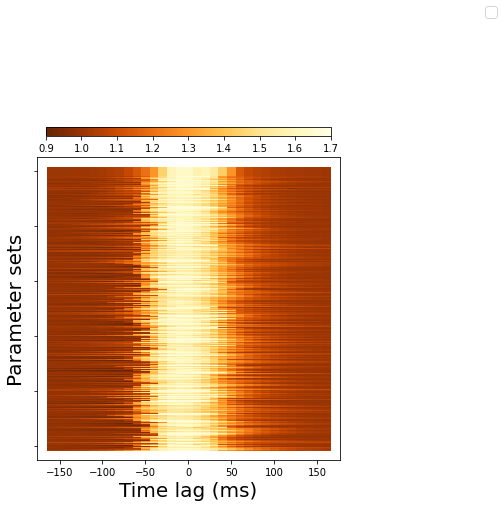

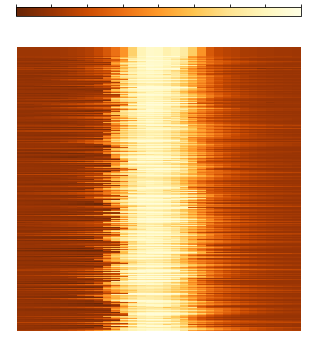

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


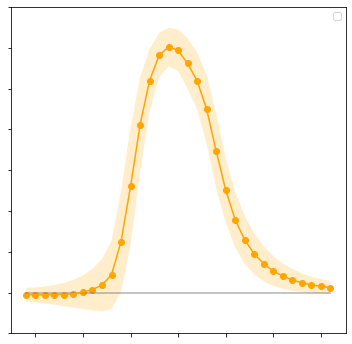

In [4]:
#calc synaptic changes by learning rules
import matplotlib as mpl


lr_p = "a0.7t50"
savedir ="../simple_model/"
lr_li = ["Hebbian", "Anti-Hebbian", "STDP", "Anti-STDP"]

dx_li =[0]
    
NE = 1
test_T=3000 #offset including
offset=2000
T = 3000 #offset including

dt = 0.1
lag_step=10
lag_li = np.arange(-160, 170, lag_step)

peak =13  #12.692
fx,fy = int(-0.8/dt),-68  #down to up
lx,ly = int(0.8/dt), -76  #down
vrest = -70

off = 200 #ms 
n=3
interval = 1000 #ms
stim_T = n *interval

colors =["orange", "blue", "magenta", "green" ]
cmap_li =["YlOrBr_r", "Blues_r", "PuRd_r", "Greens_r" ]



N=1000

for lr_in in range(4):
#     if lr_in == 2:
#         continue
#     lr_in = 0
    # pd_lr = pd_params[pd_params["lr"]==lr_in]
    pd_lr = pd.read_excel(savedir+lr_li[lr_in]+"_"+lr_p+".xlsx")

    if lr_in ==0:
        vmin = 0.9
        vmax = 1.7

    elif lr_in==1:
        vmin = 0.3
        vmax = 1.1
    else:
        vmin = 0.3
        vmax = 1.7

    fig = plt.figure(figsize=(6, 6))
    ax  = fig.add_axes((0.05, 0.15, 0.7, 0.7))

    min_esq_li=np.zeros(N)
    sync_li= []#np.zeros(N)

    for i in range(N):
            if i%100 == 0:
                print("i", i)

            if __name__ == "__main__":

                pd_param =pd_lr.iloc[i,2:10]
                pars = pd_param.to_dict()
                cpre_r,cpost_r = 1,1
                lag=100
                spikes_stim = gen_spikes(stim_T,off,dt,n,interval,lag)
                vpre, vpost =sp_to_mp_2(spikes_stim, stim_T, off, peak, fx, fy, lx, ly, vrest)
                area_class = area_gd(pars, test_T, offset, dt,cpre_r, cpost_r, 1)
                pars, cpre_t, cpost_t = area_class.run_ode_np_area(vpre, vpost)
                cpre_r = 0.7/np.max(cpre_t[int(offset/dt):int(test_T/dt)])
                cpost_r = 1.4/np.max(cpost_t[int(offset/dt):int(test_T/dt)])

                tau_ca_pre  = pars['tau_ca_pre']
                tau_ca_post  = pars['tau_ca_post']
                tau_s  = pars['tau_s'] 
                sig = pars['sig']
                th_d, th_p = pars['th_d'], pars['th_p']
                gd, gp = pars['gd'], pars['gp']
    #             if gd > gd_r[1]:
    #                 continue
                results=[]
                manager = multiprocessing.Manager()
                syn_c_dic = manager.dict()
                for lag in lag_li:
                    fs=20
                    p = Process(target=run_ode_lr, args=(lag, T, offset, dt, cpre_r, cpost_r, vpre, vpost,  syn_c_dic,gp, gd, th_p, th_d, tau_ca_pre, tau_ca_post, sig, tau_s))
    #                

                    p.start()
                    results.append(p)

                for p in results:
                    p.join()

                a = syn_c_dic.items()
                #print("syncdic", a)
                new_dic = sorted(a)
                syn_c_sorted = np.array([i[1] for i in new_dic])
                lr_index, min_esq, min_dx = fitting_curve(lr_li, lag_li, lag_step, syn_c_sorted, amp, tau,dx_li)

                min_esq_li[i]=min_esq
                sync_li.append(syn_c_sorted)


    sortin= np.argsort(-min_esq_li)
    print(sortin)
    print("min_index", np.argmin(min_esq_li))

    for n,i in enumerate(sortin):
          syn_c_sorted_i = sync_li[i]
          y = np.ones(len(lag_li))*n
          sca = ax.scatter(lag_li, y, s=73,marker = "s", c=syn_c_sorted_i, cmap = cmap_li[lr_in], norm=Normalize(vmin=vmin, vmax=vmax))


    ax.set_xlabel('Time lag (ms)',fontsize = fs)
    ax.set_ylabel("Parameter sets", fontsize = fs)    
    cax = fig.add_axes((0.07, 0.9, 0.66, 0.02))
    cbar = plt.colorbar(sca, aspect=30,orientation='horizontal', cax = cax)
    cbar.ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(.1))
    cbar.ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter("{x:.1f}"))
    ax.axes.yaxis.set_ticklabels([])
    ax.legend(bbox_to_anchor=(1.5, 1.5), loc="upper center", borderaxespad=0, fontsize=fs_l)
    plt.show()



#article--------

    fig = plt.figure(figsize=(6, 6))
    ax  = fig.add_axes((0.05, 0.15, 0.7, 0.7))

    for n,i in enumerate(sortin):
          syn_c_sorted_i = sync_li[i]
          y = np.ones(len(lag_li))*n
          sca = ax.scatter(lag_li, y, s=73,marker = "s", c=syn_c_sorted_i, cmap = cmap_li[lr_in], norm=Normalize(vmin=vmin, vmax=vmax))


    cax = fig.add_axes((0.07, 0.9, 0.66, 0.02))
    cbar = plt.colorbar(sca, aspect=30,orientation='horizontal', cax = cax)
    # cbar.ax.set_ylim(0.2, 1.8)
    cbar.ax.xaxis.set_ticks_position('top')
    cbar.ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(.1))
    cbar.ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter("{x:.1f}"))


    ax.axis("off")
    ax = plt.gca()
    ax.axes.xaxis.set_ticklabels([])
    ax.axes.yaxis.set_ticklabels([])


    plt.savefig("lr_gra_{}_{}.SVG".format(lr_li[lr_in], lr_p))
    plt.show()

    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111)
    syn_c_M = np.mean(np.array(sync_li), axis = 0)
    syn_c_SD = np.std(np.array(sync_li), axis =0)
    yc=np.ones(len(lag_li))*1.0
    ax.plot(lag_li, yc, color = "gray", alpha=0.6)
    ax.plot(lag_li, syn_c_M, color = colors[lr_in])
    ax.scatter(lag_li, syn_c_M, c = colors[lr_in])
    ax.fill_between(lag_li, syn_c_M+syn_c_SD, syn_c_M-syn_c_SD, facecolor=colors[lr_in], alpha=0.2)

    if lr_in ==2 or lr_in ==3:
        plt.ylim(0.3, 1.7)
    elif lr_in == 1:     
        plt.ylim(0.3, 1.1)
    else:
        plt.ylim(0.9, 1.7)

    ax = plt.gca()
    ax.axes.xaxis.set_ticklabels([])
    ax.axes.yaxis.set_ticklabels([])
    plt.legend()
    plt.savefig("lr_normSD_{}_{}.SVG".format(lr_li[lr_in], lr_p))
    plt.show()